   age  experience education_level job_level department   job_role  \
0   59          33     High School       Mid      Sales    Manager   
1   49          26        Bachelor    Senior    Finance  Developer   
2   35          16        Bachelor    Junior  Marketing    Analyst   
3   28          23          Master    Senior      Sales    Analyst   
4   41          24        Bachelor      Lead  Marketing    Analyst   

   performance_rating  projects_completed  certifications  weekly_hours  ...  \
0                   4                  40               2            36  ...   
1                   1                  26               2            52  ...   
2                   4                  16               3            58  ...   
3                   2                  28               8            36  ...   
4                   2                   1               4            43  ...   

   team_size  leadership_score  skill_match_score  years_in_role  promotions  \
0          8      

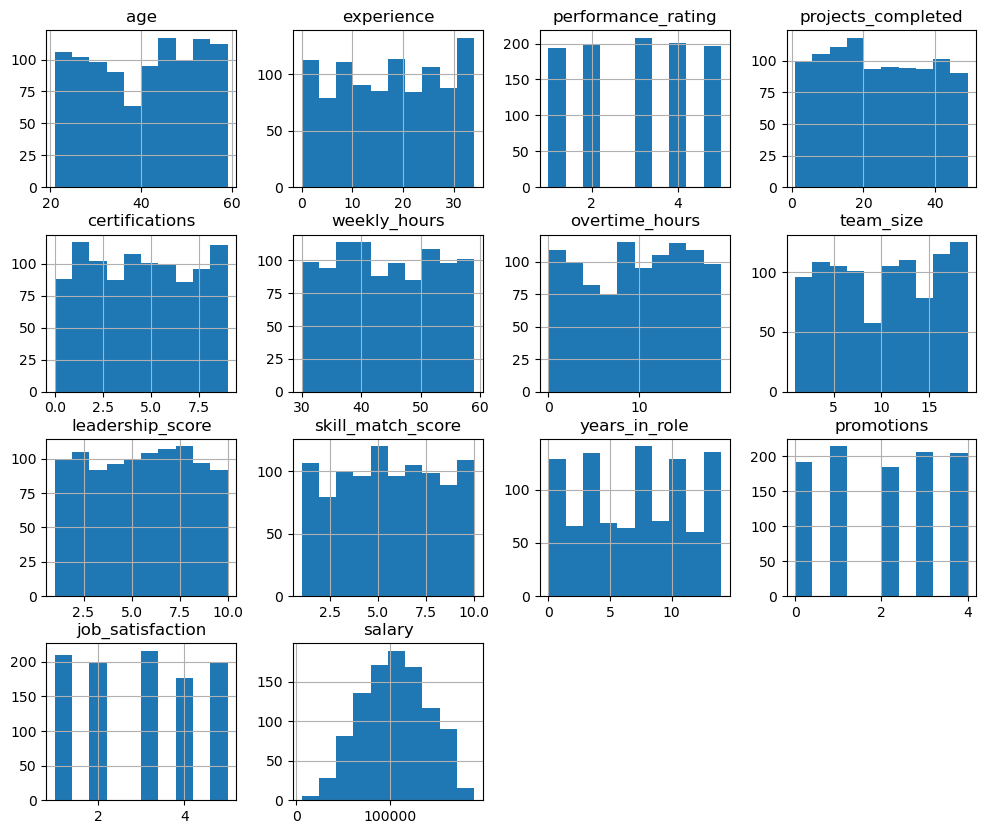

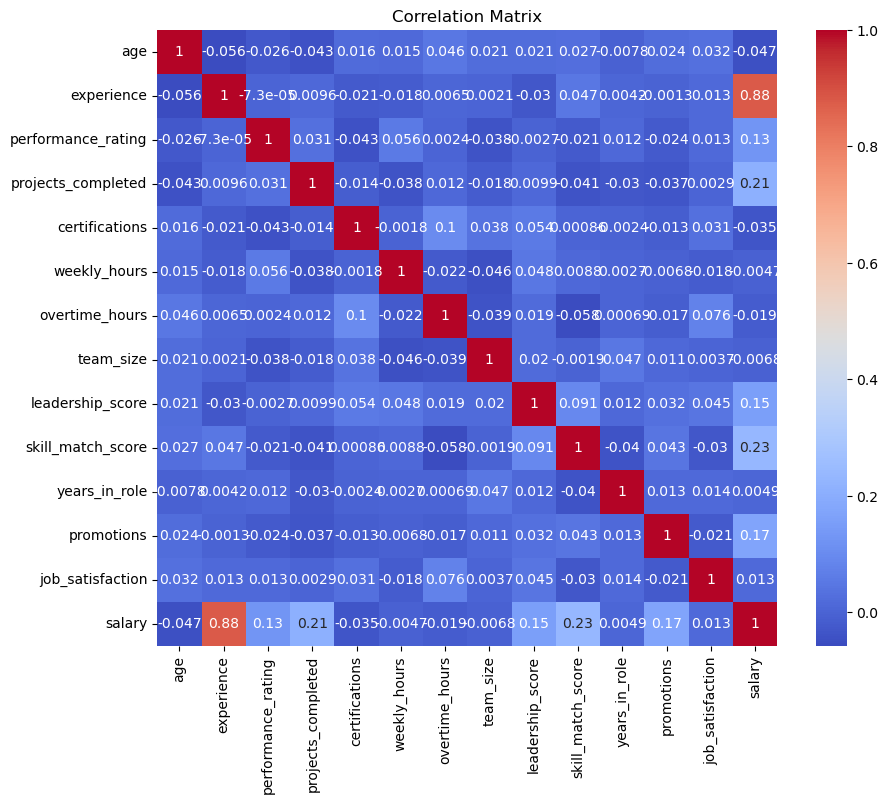

In [2]:
# PHASE 1: DATA PREPROCESSING & EDA

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("employee_salary_dataset_1000.csv")

# Basic info
print(data.head())
print(data.info())
print(data.describe())

# Check missing values
print(data.isnull().sum())

# ---------------- EDA ---------------- #

# Histogram
data.hist(figsize=(12,10))
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ---------------- Preprocessing ---------------- #

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = data.drop("salary", axis=1)
y = data["salary"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [3]:
# PHASE 2: FEATURE SELECTION + MODEL TRAINING

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.feature_selection import SequentialFeatureSelector, SelectKBest, f_regression

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------- Feature Selection (Forward Selection) -------- #

lin_reg = LinearRegression()

sfs = SequentialFeatureSelector(
    lin_reg,
    n_features_to_select=10,
    direction="forward"
)

fs_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", sfs),
    ("model", lin_reg)
])

fs_pipeline.fit(X_train, y_train)

# -------- Random Forest with GridSearch -------- #

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, 10, None]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=3,
    scoring="r2"
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# -------- SVR with Feature Selection + GridSearch -------- #

svr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_regression, k=15)),
    ("model", SVR(kernel='rbf'))
])

param_grid_svr = {
    "model__C": [10, 100, 500],
    "model__gamma": [0.1, 0.01, 0.001],
    "model__epsilon": [0.1, 0.5, 1]
}

grid_svr = GridSearchCV(
    svr_pipeline,
    param_grid_svr,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_svr.fit(X_train, y_train)

best_svr = grid_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test)